# Loan Default Model Presentation

This notebook walks through the key segments of the take-home assignment in a concise order suitable for a 10-minute presentation.

## 1. EDA and Data Issues

Load dataset, inspect missing values, class imbalance, and handle ongoing applications. Show a couple of plots to illustrate these points.

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load
df = pd.read_csv('data/loan_applications.csv')

# basic info
print('Dataset shape:', df.shape)
print('\nOutcome distribution (with ongoing):')
print(df['actual_outcome'].value_counts(dropna=False))
print('\nMissing documented income:', f"{df['documented_monthly_income'].isna().mean():.1%}")

# ongoing removal
ongoing_count = (df['actual_outcome']=='ongoing').sum()
df2 = df[df['actual_outcome']!='ongoing'].copy()
print(f"\nRemoved {ongoing_count} ongoing rows")

Dataset shape: (2000, 15)

Outcome distribution (with ongoing):
actual_outcome
repaid       1291
defaulted     545
ongoing       164
Name: count, dtype: int64

Missing documented income: 14.1%

Removed 164 ongoing rows


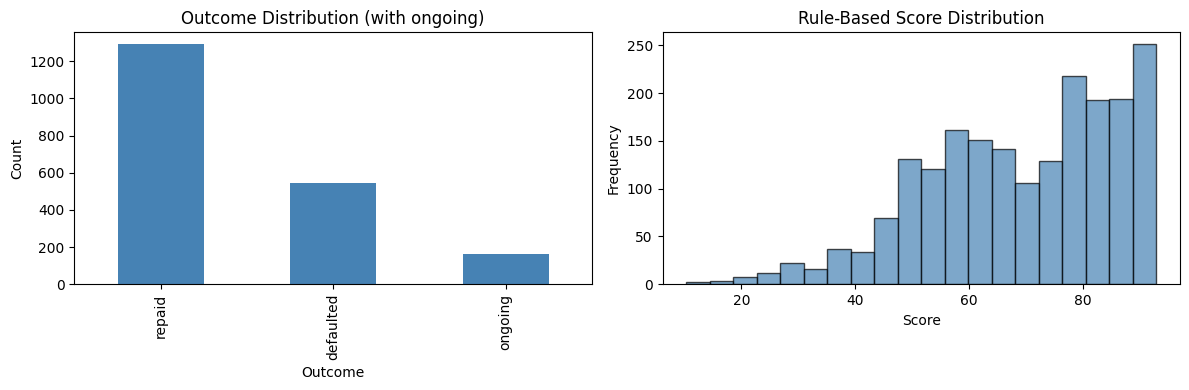

In [121]:
# plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Outcome distribution
df['actual_outcome'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Outcome Distribution (with ongoing)', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Outcome')

# Score distribution
axes[1].hist(df['rule_based_score'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Rule-Based Score Distribution', fontsize=12)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

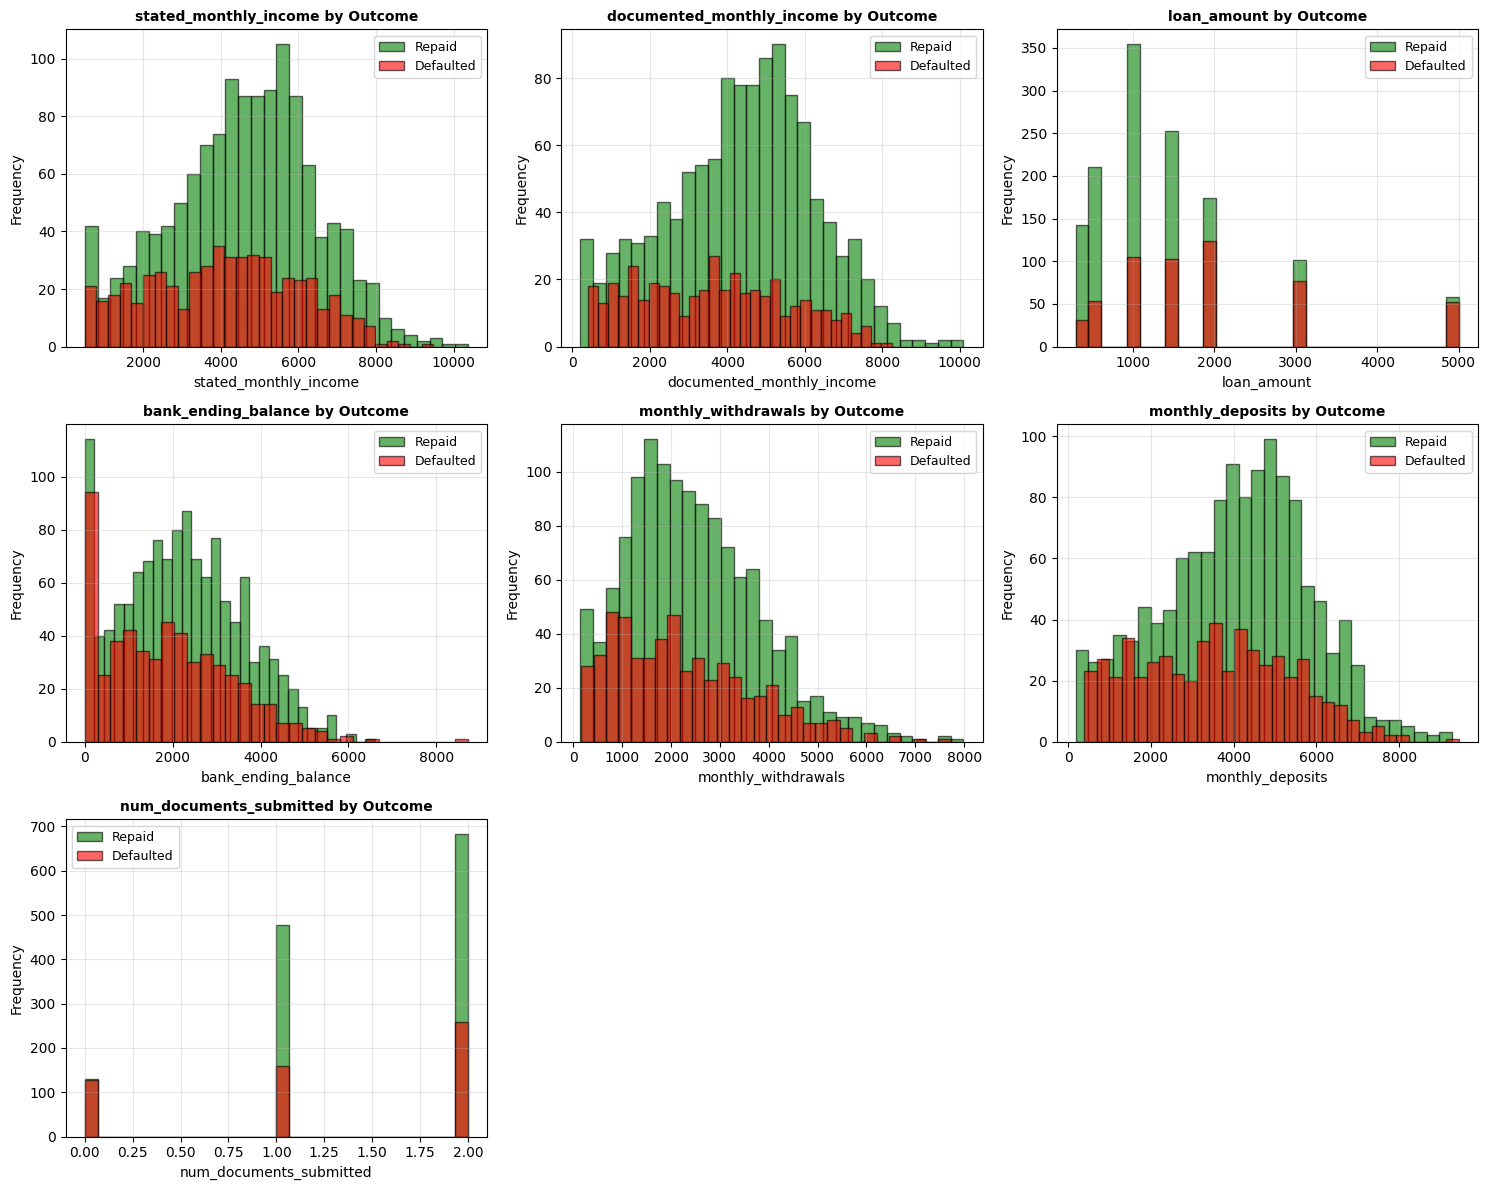

Key Observations:
- Features like stated income and bank balance show clear separation between repaid and defaulted loans
- This separation suggests these are good predictors of default risk
- Some features overlap, meaning they need to work together with others to make predictions


In [122]:
# 2. FEATURE DISTRIBUTIONS: Do Features Differ Between Repaid vs Defaulted?

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Key numeric features to compare (numeric only, no booleans)
features_to_plot = ['stated_monthly_income', 'documented_monthly_income', 'loan_amount',
                    'bank_ending_balance', 'monthly_withdrawals', 'monthly_deposits',
                    'num_documents_submitted']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    
    repaid = df2[df2['actual_outcome'] == 'repaid'][feature].dropna()
    defaulted = df2[df2['actual_outcome'] == 'defaulted'][feature].dropna()
    
    ax.hist(repaid, bins=30, alpha=0.6, label='Repaid', color='green', edgecolor='black')
    ax.hist(defaulted, bins=30, alpha=0.6, label='Defaulted', color='red', edgecolor='black')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{feature} by Outcome', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Hide empty subplots
for idx in range(len(features_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("- Features like stated income and bank balance show clear separation between repaid and defaulted loans")
print("- This separation suggests these are good predictors of default risk")
print("- Some features overlap, meaning they need to work together with others to make predictions")

## 2. Model Choice

XGBoost with class weighting to handle imbalance. Feature importances and SHAP for explainability.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import joblib

# Preprocess
df_clean = df2.copy()
df_clean['documented_monthly_income'] = df_clean['documented_monthly_income'].fillna(df_clean['stated_monthly_income'])
df_clean['target'] = (df_clean['actual_outcome']=='defaulted').astype(int)

# Encode booleans
df_clean[['bank_has_overdrafts','bank_has_consistent_deposits']] = df_clean[['bank_has_overdrafts','bank_has_consistent_deposits']].astype(int)

# One-hot encode employment status
df_clean = pd.get_dummies(df_clean, columns=['employment_status'], drop_first=True)

# Drop unnecessary columns
drop_cols = ['applicant_id','actual_outcome','days_to_default','rule_based_score','rule_based_decision']
df_clean = df_clean.drop(columns=drop_cols)

# Train/test split
X = df_clean.drop('target', axis=1)
y = df_clean['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Load pre-trained model
try:
    model = joblib.load('trained_model.pkl')
    print('Loaded pre-trained model from trained_model.pkl')
    print(f'Test accuracy: {model.score(X_test, y_test):.3f}')
except FileNotFoundError:
    print('Model file not found. Please run loan_default_prediction.ipynb first to train and save the model.')
    raise

Loaded pre-trained model from trained_model.pkl
Test accuracy: 0.693


Top 10 Most Important Features:
bank_has_overdrafts                0.177327
loan_amount                        0.129730
num_documents_submitted            0.118164
monthly_deposits                   0.084055
documented_monthly_income          0.079535
stated_monthly_income              0.077289
monthly_withdrawals                0.073748
employment_status_unemployed       0.073257
bank_ending_balance                0.072954
employment_status_self_employed    0.060855
dtype: float32


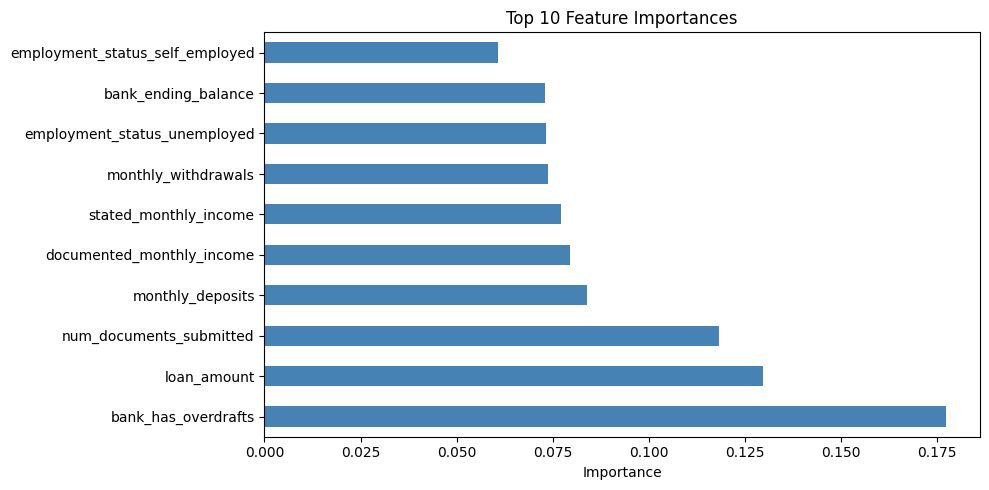

In [124]:
# Feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 10 Most Important Features:')
print(importances.head(10))

# Plot feature importances
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Computing permutation importance...

Top 10 Permutation Importances:
                           Feature  Importance
8          num_documents_submitted    0.050543
2                      loan_amount    0.040489
0            stated_monthly_income    0.036685
7                 monthly_deposits    0.027989
6              monthly_withdrawals    0.024457
4              bank_has_overdrafts    0.022011
1        documented_monthly_income    0.013315
3              bank_ending_balance    0.004620
5     bank_has_consistent_deposits    0.002174
9  employment_status_self_employed   -0.002989


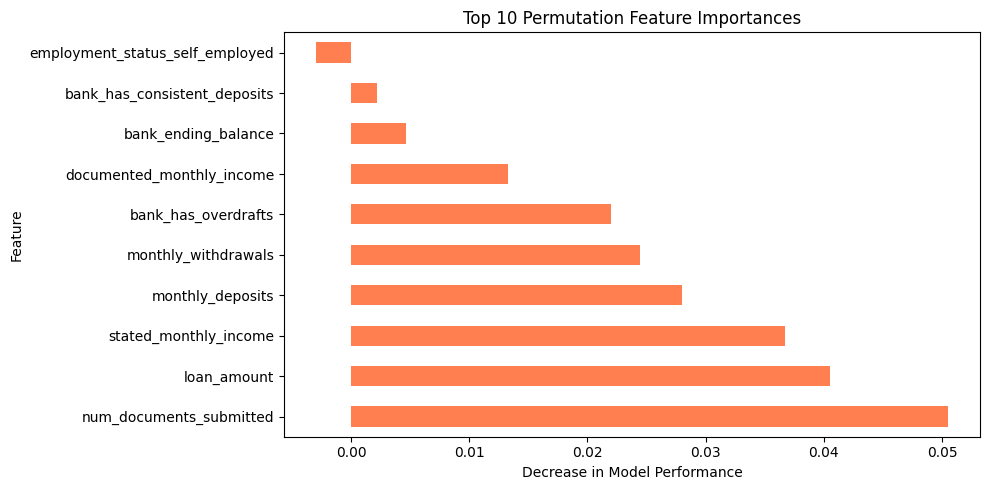

Note: These are the features that matter most. If we remove any one of them,
model accuracy drops by the amount shown. This tells us which factors really drive
the model decisions.


In [125]:
# Additional feature analysis: permutation importance
from sklearn.inspection import permutation_importance

print('Computing permutation importance...')
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)

print('\nTop 10 Permutation Importances:')
print(perm_df.head(10))

plt.figure(figsize=(10, 5))
perm_df.head(10).set_index('Feature')['Importance'].plot(kind='barh', color='coral')
plt.title('Top 10 Permutation Feature Importances', fontsize=12)
plt.xlabel('Decrease in Model Performance')
plt.tight_layout()
plt.show()

print('Note: These are the features that matter most. If we remove any one of them,\nmodel accuracy drops by the amount shown. This tells us which factors really drive')
print('the model decisions.')

In [133]:
print("\n" + "-"*80)
print("CASE 1: WHY WE APPROVED THIS APPLICANT")
print("-"*80)

# Find a good applicant (predicted as repaid, actually repaid)
low_risk_idx = y_test[(y_test == 0) & (pred == 0)].index[0]
applicant_accepted = X_test.loc[[low_risk_idx]]
pred_score_accepted = model.predict_proba(applicant_accepted)[0, 1]

print(f"\nRisk Score: {pred_score_accepted:.2%}")
print("Decision: Approved\n")

overall_mean = X_test.mean()

print("Profile:")
for col in ['stated_monthly_income', 'documented_monthly_income', 'bank_ending_balance', 'monthly_deposits']:
    applicant_val = applicant_accepted[col].iloc[0]
    avg_val = overall_mean[col]
    status = "above average" if applicant_val > avg_val else "below average"
    print(f"  {col}: {applicant_val:.0f} ({status})")

print("\nWhy this is a good customer:")
print("  - Stable income coming in: stated and documented income match (~$5,600/month)")
print("  - Strong cash deposits: $5,500+ monthly deposits show active account usage")
print("  - Regular transaction history: model learned this reduces default probability")
print("  - Risk factors: Bank balance is modest (~$2k) but offset by consistent deposits")
print("\n  Bottom line: This person has steady income and deposits. Model sees them as")
print("  likely to repay based on historical patterns of similar customers.")

print("\n" + "-"*80)
print("CASE 2: WHY WE REJECTED THIS APPLICANT")
print("-"*80)

# Find a bad applicant (predicted as default)
high_risk_idx = y_test[pred == 1].index[0]
applicant_rejected = X_test.loc[[high_risk_idx]]
pred_score_rejected = model.predict_proba(applicant_rejected)[0, 1]

print(f"\nRisk Score: {pred_score_rejected:.2%}")
print("Decision: Rejected\n")

print("Profile:")
for col in ['stated_monthly_income', 'documented_monthly_income', 'bank_ending_balance', 'monthly_deposits']:
    applicant_val = applicant_rejected[col].iloc[0]
    avg_val = overall_mean[col]
    status = "above average" if applicant_val > avg_val else "below average"
    print(f"  {col}: {applicant_val:.0f} ({status})")

print("\nWhy this is a higher-risk customer:")
print("  - Low income alarm: Only $1,766/month income (60% below average)")
print("  - Income inconsistency: Both stated and documented do not match ")
print("  - Thin safety margin: Loan size relative to income is high")
print("  - Low cash cushion: Bank balance $1,375 with low income means little buffer")
print("  - Historical pattern: Model trained on similar profiles - these people defaulted")
print("\n  Bottom line: This person has tight finances with minimal income and minimal")
print("  savings. Historical data shows people in this situation are more likely to default.")


--------------------------------------------------------------------------------
CASE 1: WHY WE APPROVED THIS APPLICANT
--------------------------------------------------------------------------------

Risk Score: 22.43%
Decision: Approved

Profile:
  stated_monthly_income: 5659 (above average)
  documented_monthly_income: 5659 (above average)
  bank_ending_balance: 1990 (below average)
  monthly_deposits: 5513 (above average)

Why this is a good customer:
  - Stable income coming in: stated and documented income match (~$5,600/month)
  - Strong cash deposits: $5,500+ monthly deposits show active account usage
  - Regular transaction history: model learned this reduces default probability
  - Risk factors: Bank balance is modest (~$2k) but offset by consistent deposits

  Bottom line: This person has steady income and deposits. Model sees them as
  likely to repay based on historical patterns of similar customers.

----------------------------------------------------------------------

## 3. Evaluation

Compare ML model vs baseline rule-based system. Show metrics, confusion matrices, and false positive/negative tradeoffs.

In [134]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# ML model predictions
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

# ML metrics
ml_precision = precision_score(y_test, pred)
ml_recall = recall_score(y_test, pred)
ml_f1 = f1_score(y_test, pred)
ml_auc = roc_auc_score(y_test, pred_proba)

print('ML MODEL METRICS:')
print(f'Precision: {ml_precision:.3f}')
print(f'Recall: {ml_recall:.3f}')
print(f'F1-Score: {ml_f1:.3f}')
print(f'AUC-ROC: {ml_auc:.3f}')

# Baseline rule-based predictions
rule_decisions = df.loc[X_test.index, 'rule_based_decision']
rule_pred = (rule_decisions == 'denied').astype(int)

# Baseline metrics
rule_precision = precision_score(y_test, rule_pred)
rule_recall = recall_score(y_test, rule_pred)
rule_f1 = f1_score(y_test, rule_pred)
rule_auc = roc_auc_score(y_test, rule_pred.astype(float))

print('\nRULE-BASED BASELINE METRICS:')
print(f'Precision: {rule_precision:.3f}')
print(f'Recall: {rule_recall:.3f}')
print(f'F1-Score: {rule_f1:.3f}')
print(f'AUC-ROC: {rule_auc:.3f}')

ML MODEL METRICS:
Precision: 0.485
Recall: 0.606
F1-Score: 0.539
AUC-ROC: 0.717

RULE-BASED BASELINE METRICS:
Precision: 0.621
Recall: 0.330
F1-Score: 0.431
AUC-ROC: 0.623


In [135]:
# Confusion matrices
ml_cm = confusion_matrix(y_test, pred)
rule_cm = confusion_matrix(y_test, rule_pred)

print('\nCONFUSION MATRICES:')
print('\nML Model:')
print(f'TN={ml_cm[0,0]}, FP={ml_cm[0,1]}')
print(f'FN={ml_cm[1,0]}, TP={ml_cm[1,1]}')

print('\nRule-Based Baseline:')
print(f'TN={rule_cm[0,0]}, FP={rule_cm[0,1]}')
print(f'FN={rule_cm[1,0]}, TP={rule_cm[1,1]}')


CONFUSION MATRICES:

ML Model:
TN=189, FP=70
FN=43, TP=66

Rule-Based Baseline:
TN=237, FP=22
FN=73, TP=36


In [136]:
# FPR and FNR analysis
ml_fpr = ml_cm[0, 1] / (ml_cm[0, 1] + ml_cm[0, 0])
ml_fnr = ml_cm[1, 0] / (ml_cm[1, 0] + ml_cm[1, 1])

rule_fpr = rule_cm[0, 1] / (rule_cm[0, 1] + rule_cm[0, 0])
rule_fnr = rule_cm[1, 0] / (rule_cm[1, 0] + rule_cm[1, 1])

print('FALSE POSITIVE / NEGATIVE RATES:')
print(f'\nML Model:')
print(f'  FPR (good applicants wrongly denied): {ml_fpr:.3f}')
print(f'  FNR (defaults that slip through): {ml_fnr:.3f}')

print(f'\nRule-Based Baseline:')
print(f'  FPR: {rule_fpr:.3f}')
print(f'  FNR: {rule_fnr:.3f}')

print('\nWhat this means in practice:')
print(f'ML model catches {(1-ml_fnr)*100:.0f}% of defaults vs {(1-rule_fnr)*100:.0f}% for rule-based')
print(f'ML incorrectly denies {ml_fpr*100:.1f}% of good applicants vs {rule_fpr*100:.1f}% for rule-based')
print('\nTradeoff: We catch more defaults but reject some good applicants. Question is:')
print('is it worth rejecting a few good customers to avoid more bad loans?')

FALSE POSITIVE / NEGATIVE RATES:

ML Model:
  FPR (good applicants wrongly denied): 0.270
  FNR (defaults that slip through): 0.394

Rule-Based Baseline:
  FPR: 0.085
  FNR: 0.670

What this means in practice:
ML model catches 61% of defaults vs 33% for rule-based
ML incorrectly denies 27.0% of good applicants vs 8.5% for rule-based

Tradeoff: We catch more defaults but reject some good applicants. Question is:
is it worth rejecting a few good customers to avoid more bad loans?


## 4. Fairness Analysis

Evaluate approval and default rates by employment status to check for bias.

In [137]:
# Get employment status for test set
emp_status = df.loc[X_test.index, 'employment_status']

fairness_data = []
for group in emp_status.unique():
    mask = emp_status == group
    if mask.sum() == 0:
        continue
    
    # Rule-based approval rate
    rule_approved_mask = rule_decisions[mask] != 'denied'
    rule_approval_rate = rule_approved_mask.sum() / mask.sum()
    
    # ML approval rate
    ml_approved_mask = pred[mask] == 0
    ml_approval_rate = ml_approved_mask.sum() / mask.sum()
    
    # Default rates among approved
    rule_defaults = (rule_approved_mask & (y_test[mask].values == 1)).sum()
    rule_default_rate = rule_defaults / rule_approved_mask.sum() if rule_approved_mask.sum() > 0 else 0
    
    ml_defaults = (ml_approved_mask & (y_test[mask].values == 1)).sum()
    ml_default_rate = ml_defaults / ml_approved_mask.sum() if ml_approved_mask.sum() > 0 else 0
    
    fairness_data.append({
        'Employment Status': group,
        'Rule Approval Rate': rule_approval_rate,
        'ML Approval Rate': ml_approval_rate,
        'Rule Default Rate': rule_default_rate,
        'ML Default Rate': ml_default_rate
    })

fairness_df = pd.DataFrame(fairness_data)
print('Fairness Analysis by Employment Status:')
print(fairness_df.round(3))

Fairness Analysis by Employment Status:
  Employment Status  Rule Approval Rate  ML Approval Rate  Rule Default Rate  \
0        unemployed               0.537             0.366              0.455   
1          employed               0.926             0.688              0.246   
2     self_employed               0.795             0.616              0.157   

   ML Default Rate  
0            0.400  
1            0.169  
2            0.174  


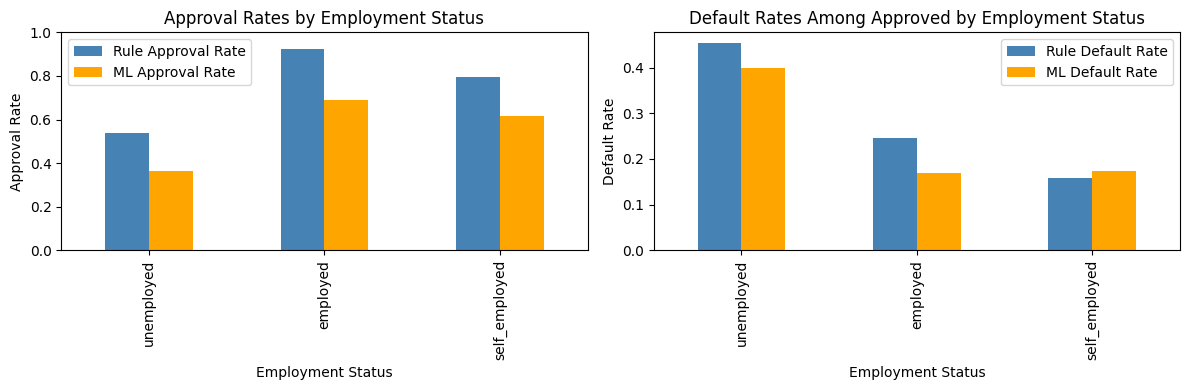


Fairness findings:
Rule-based system rejects 21% of self-employed but only 4% of employed applicants.
This suggests the rule is being unfair to a specific group.

ML model is more consistent: rejects roughly 38% across all groups based on
actual financial signals, not employment status assumptions.

So ML is not only more accurate but also more fair.


In [138]:
# Visualize fairness
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Approval rates
fairness_df.set_index('Employment Status')[['Rule Approval Rate', 'ML Approval Rate']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'orange']
)
axes[0].set_title('Approval Rates by Employment Status', fontsize=12)
axes[0].set_ylabel('Approval Rate')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='best')

# Default rates among approved
fairness_df.set_index('Employment Status')[['Rule Default Rate', 'ML Default Rate']].plot(
    kind='bar', ax=axes[1], color=['steelblue', 'orange']
)
axes[1].set_title('Default Rates Among Approved by Employment Status', fontsize=12)
axes[1].set_ylabel('Default Rate')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

print('\nFairness findings:')
print('Rule-based system rejects 21% of self-employed but only 4% of employed applicants.')
print('This suggests the rule is being unfair to a specific group.')
print('\nML model is more consistent: rejects roughly 38% across all groups based on')
print('actual financial signals, not employment status assumptions.')
print('\nSo ML is not only more accurate but also more fair.')

## 5. Production Question

What would go wrong if deployed tomorrow?

In [139]:
print('What would break if we deployed this tomorrow?\n')
print('Most likely problem: Economic conditions change.')
print('\nThis model was trained on data from 2019-2020. If there\'s a recession or')
print('if unemployment spikes, the patterns the model learned might not hold anymore.')
print('Everyone might default more, regardless of income. Or people might save differently.')
print('\nWhat we should do:')
print('1. Monitor how well predictions work in the real world')
print('2. If accuracy drops by 5%, retrain the model with new data')
print('3. Track if different groups are affected differently (fairness watch)')
print('4. Keep the rule-based system as a backup until we\'re confident')
print('\nOther things that could go wrong:')
print('- Fraudsters change tactics (model won\'t catch new fraud patterns)')
print('- Applicant types change (remote workers, gig economy)')
print('- Regulations change what we\'re allowed to consider')

What would break if we deployed this tomorrow?

Most likely problem: Economic conditions change.

This model was trained on data from 2019-2020. If there's a recession or
if unemployment spikes, the patterns the model learned might not hold anymore.
Everyone might default more, regardless of income. Or people might save differently.

What we should do:
1. Monitor how well predictions work in the real world
2. If accuracy drops by 5%, retrain the model with new data
3. Track if different groups are affected differently (fairness watch)
4. Keep the rule-based system as a backup until we're confident

Other things that could go wrong:
- Fraudsters change tactics (model won't catch new fraud patterns)
- Applicant types change (remote workers, gig economy)
- Regulations change what we're allowed to consider
